# Customer Churn Prediction - Exploratory Data Analysis

## Objective

The preprocessing stage cleaned the raw customer data and removed features that were irrelevant, redundant, or potentially affected by target leakage.

The goal of this notebook is to understand the relationships between customer characteristics and churn before moving on to feature engineering.

This notebook will cover:

- Exploratory Data Analysis (EDA)
- Numerical feature analysis
- Categorical feature analysis
- Relationships between features and churn
- Feature distributions and potential outliers
- Correlation and relationship analysis
- Geographic analysis

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Cleaned Dataset

The raw dataset was cleaned during the preprocessing stage. I will now use the cleaned dataset as the starting point for EDA and feature engineering.

In [2]:
df = pd.read_csv("../data/processed/telco_cleaned.csv")
df.head()

,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [3]:
df.shape

(7043, 24)

### Quick Data Check

Before starting the analysis, I will perform a quick check of the cleaned dataset to make sure the previous preprocessing steps were applied correctly.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   str    
 1   Zip Code           7043 non-null   int64  
 2   Latitude           7043 non-null   float64
 3   Longitude          7043 non-null   float64
 4   Gender             7043 non-null   str    
 5   Senior Citizen     7043 non-null   str    
 6   Partner            7043 non-null   str    
 7   Dependents         7043 non-null   str    
 8   Tenure Months      7043 non-null   int64  
 9   Phone Service      7043 non-null   str    
 10  Multiple Lines     7043 non-null   str    
 11  Internet Service   7043 non-null   str    
 12  Online Security    7043 non-null   str    
 13  Online Backup      7043 non-null   str    
 14  Device Protection  7043 non-null   str    
 15  Tech Support       7043 non-null   str    
 16  Streaming TV       7043 non-null   

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Churn Value"].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

## 3. Exploratory Data Analysis

The purpose of this section is to understand how customer characteristics and services relate to churn.

Rather than creating visualizations just for the sake of exploration, I will use them to answer specific questions about customer behavior and identify patterns that may be useful during feature engineering.

### 3.1 Target Distribution

Before analyzing individual features, I want to understand the distribution of the target variable.

This will show how many customers churned compared with those who stayed and whether the classification problem is balanced.

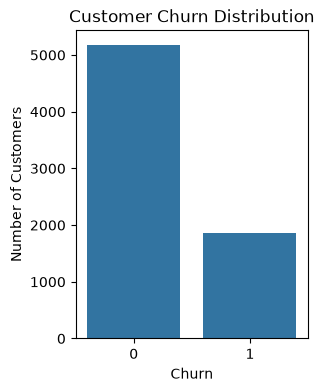

In [8]:
plt.figure(figsize= (3,4))
sns.countplot(data=df, x = 'Churn Value')
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [9]:
churn_distribution = df['Churn Value'].value_counts(normalize=True)*100
churn_distribution

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

### Observation

The majority of customers did not churn, while a smaller proportion of customers churned.

The target is therefore moderately imbalanced. Because of this, accuracy alone may not be enough to evaluate the final model. Metrics such as precision, recall, F1-score, and ROC-AUC will also be considered during model evaluation.

In [10]:
numerical_cols =df.select_dtypes(include= ["number"]).columns.tolist()
numerical_cols

['Zip Code',
 'Latitude',
 'Longitude',
 'Tenure Months',
 'Monthly Charges',
 'Total Charges',
 'Churn Value']

In [11]:
# We shouldn't analyze Churn Value as a normal numerical feature
numerical_features =[
    col for col in numerical_cols
    if (col != "Churn Value")
]
numerical_features

['Zip Code',
 'Latitude',
 'Longitude',
 'Tenure Months',
 'Monthly Charges',
 'Total Charges']

### 3.2 Numerical Feature Distributions

I will examine the distributions of the numerical features to understand their ranges, skewness, and potential outliers.

This will also help identify whether some numerical variables may benefit from transformation or feature engineering.

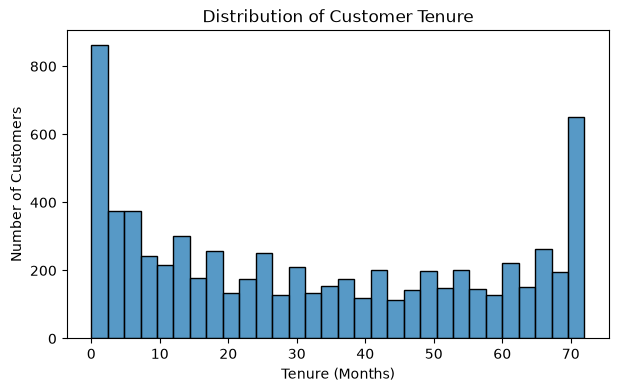

In [12]:
# First, let's look at Tenure Months
plt.figure(figsize=(7, 4))

sns.histplot(data = df , x="Tenure Months" , bins=30)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

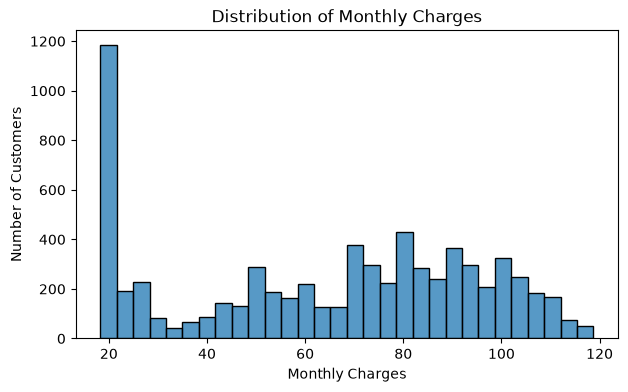

In [13]:
plt.figure(figsize=(7, 4))

sns.histplot(data=df, x="Monthly Charges", bins=30)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

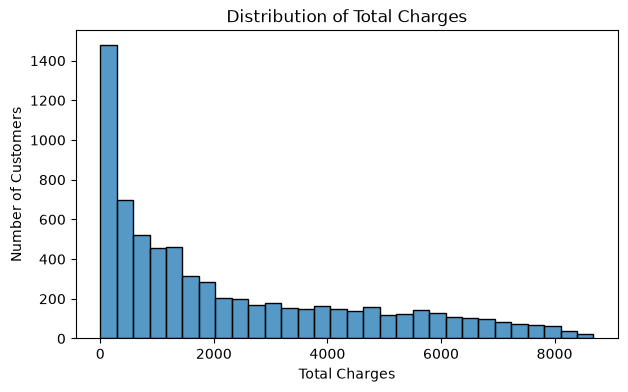

In [14]:
plt.figure(figsize=(7, 4))

sns.histplot(data=df, x="Total Charges", bins=30)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

### Key Insights: Numerical Distributions

* **Tenure Months**
  * The data forms a clear U-shape. 
  * We have a massive group of brand-new customers alongside another huge spike of long-term users hitting the 72-month cap. 
  * These peaks represent normal lifecycle stages, not data outliers.

* **Monthly Charges**
  * Most customers are heavily concentrated at the absolute minimum price bracket.
  * The rest of the customer base is spread out relatively evenly across higher tier subscription fees.

* **Total Charges**
  * The distribution is heavily right-skewed, with most balances sitting well below 2,000.
  * The long, tapering tail represents a small group of high-value accounts, which makes total sense since older customers have had years to pile up charges.


### 3.3 Numerical Features vs Churn

Understanding the distribution of individual features is useful, but for a churn prediction problem we also need to understand how these features differ between customers who churned and those who stayed.

I will compare the numerical features across the two churn groups to identify patterns that may be useful for feature engineering.

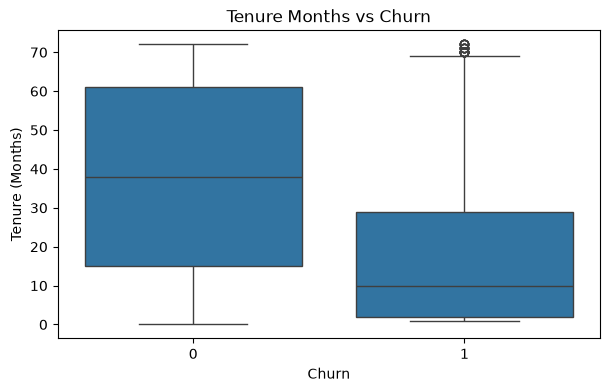

In [15]:
plt.figure(figsize=(7, 4))

sns.boxplot(
 data =df ,
 x = "Churn Value",
 y = "Tenure Months"
)
plt.title("Tenure Months vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [16]:
df.groupby("Churn Value")["Tenure Months"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


### Observation

There is a clear difference in tenure between customers who churn and those who stay.

Customers who churn generally have much lower tenure. Their tenure is heavily concentrated in the early months of their relationship with the company.

In comparison, customers who do not churn have a much wider tenure distribution and a substantially higher median tenure.

This suggests that customer tenure is strongly associated with churn, with newer customers appearing more likely to churn than long-term customers.

### Monthly Charges vs Churn

After examining tenure, I will now compare monthly charges between customers who churned and those who stayed.

The goal is to determine whether customers with different monthly charges show different churn patterns.

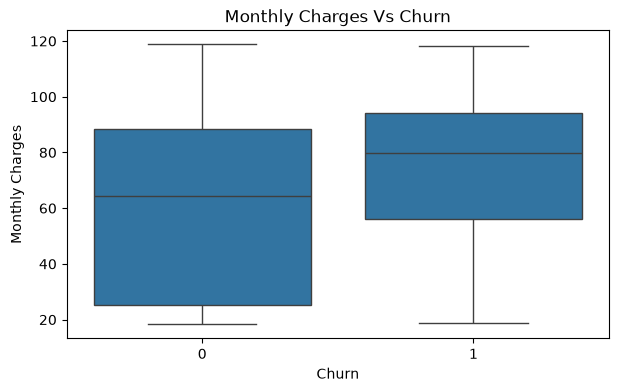

In [17]:
plt.figure(figsize = (7,4))

sns.boxplot(
    data = df ,
    x = "Churn Value",
    y = "Monthly Charges"
)
plt.title("Monthly Charges Vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [18]:
df.groupby("Churn Value")["Monthly Charges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


### Observation

Customers who churn tend to have higher monthly charges than customers who stay.

The median monthly charge is higher for the churned group, and the middle 50% of churned customers is also shifted toward higher charges.

This suggests that higher monthly charges may be associated with a greater likelihood of churn. However, monthly charges alone do not explain churn, so this relationship should be considered together with other customer and service features.

### Total Charges vs Churn

I will now compare the total charges accumulated by customers who churned and those who stayed.

Since total charges are influenced by both the customer's tenure and monthly charges, I expect this feature to behave differently from monthly charges.

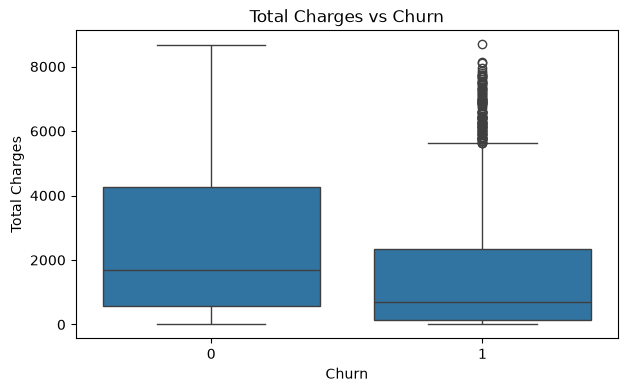

In [19]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="Churn Value",
    y="Total Charges"
)

plt.title("Total Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

In [20]:
df.groupby("Churn Value")["Total Charges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
1,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


### Observation

Customers who churn generally have much lower total charges than customers who stay.

The median total charges for customers who stayed is around 1,680, while the median for churned customers is around 704. The churned group also has a much smaller upper quartile.

This pattern is consistent with the earlier finding that churned customers generally have lower tenure. Since total charges accumulate over time, customers who leave earlier naturally tend to have lower total charges.

### 3.4 Categorical Features vs Churn

The dataset contains several categorical features describing customer demographics, services, contracts, and payment methods.

Rather than analyzing these features individually at first, I will compare the churn rate across their categories to identify the strongest patterns. The most interesting relationships can then be investigated in more detail.

In [21]:
# Categorical columns
categorical_features = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

categorical_features

['City',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method']

In [22]:
# Let's calculate churn rate for different categorical columns
for col in categorical_features:
    if( col == "City"):
        continue

    churn_rate = df.groupby(col)["Churn Value"].mean().sort_values(ascending=False)
    print((churn_rate*100).round(2))
    print()

Gender
Female    26.92
Male      26.16
Name: Churn Value, dtype: float64

Senior Citizen
Yes    41.68
No     23.61
Name: Churn Value, dtype: float64

Partner
No     32.96
Yes    19.66
Name: Churn Value, dtype: float64

Dependents
No     32.55
Yes     6.52
Name: Churn Value, dtype: float64

Phone Service
Yes    26.71
No     24.93
Name: Churn Value, dtype: float64

Multiple Lines
Yes                 28.61
No                  25.04
No phone service    24.93
Name: Churn Value, dtype: float64

Internet Service
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn Value, dtype: float64

Online Security
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn Value, dtype: float64

Online Backup
No                     39.93
Yes                    21.53
No internet service     7.40
Name: Churn Value, dtype: float64

Device Protection
No                     39.13
Yes                    22.50
No internet service     7.40
Name: Churn 

In [23]:
# Currently I am skipping City because it has a lot of unique values. Later I will deal with it separately.

categorical_features_for_eda = [
    col for col in categorical_features
    if col != "City"
]

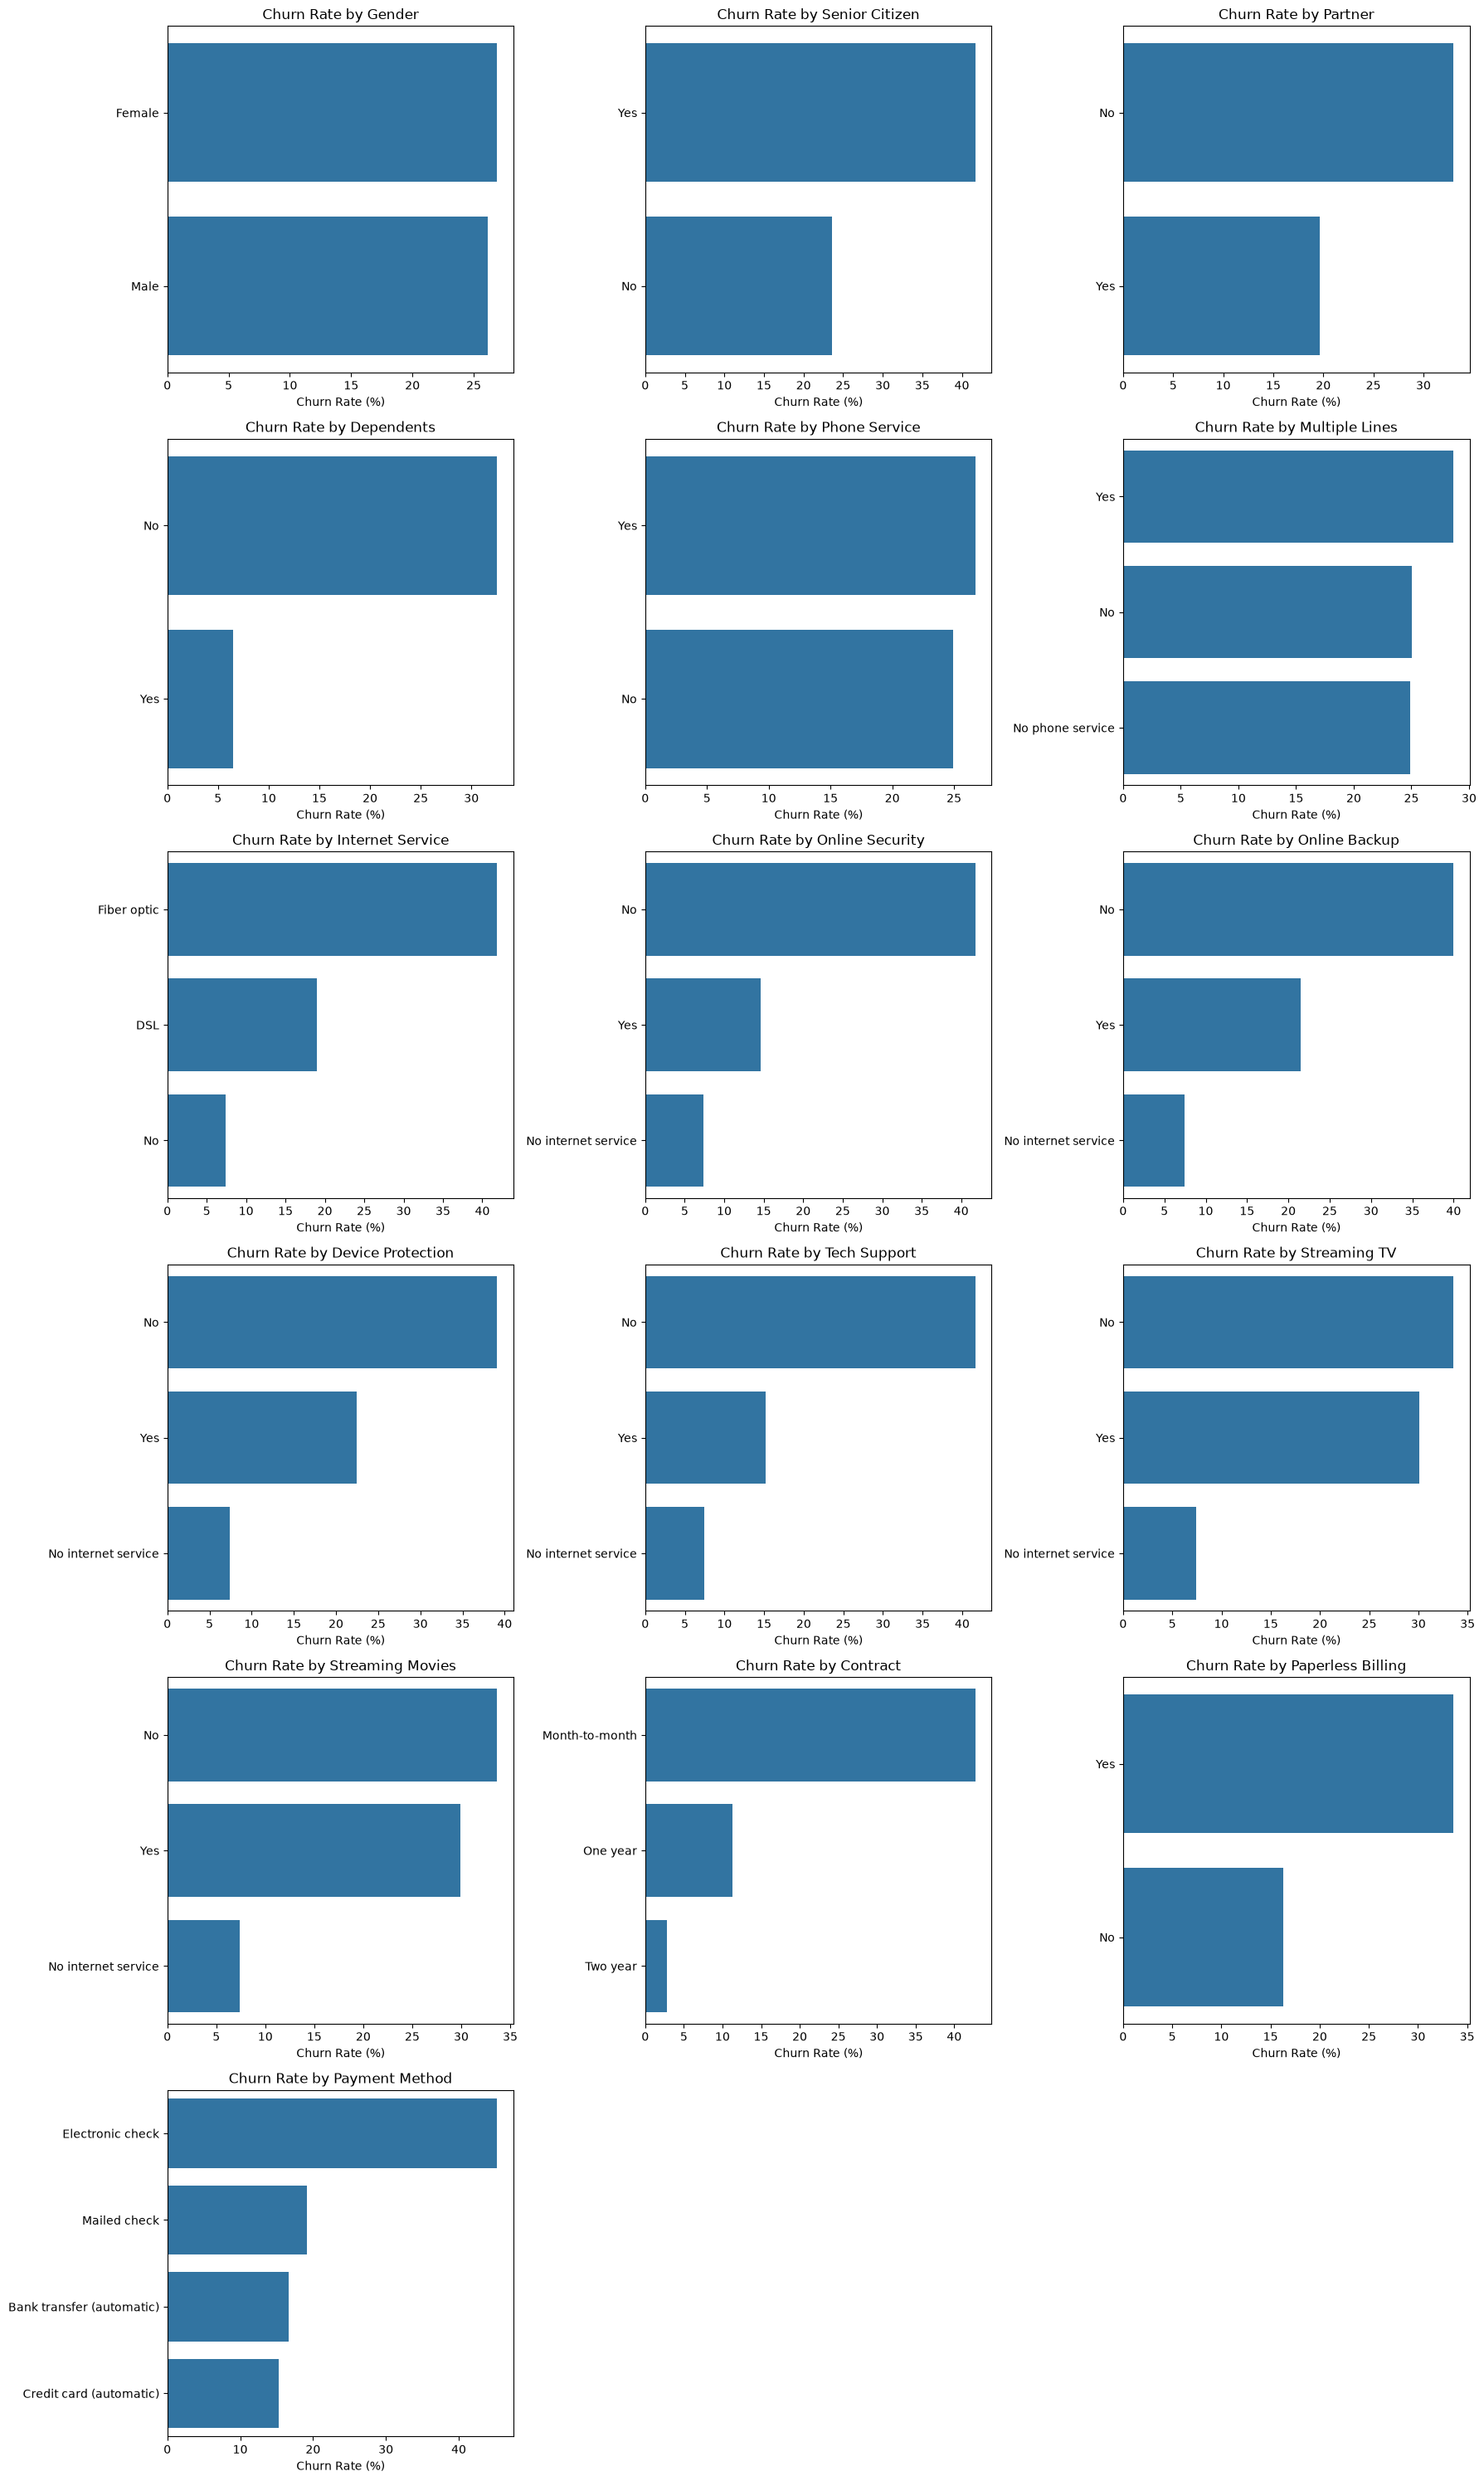

In [24]:
n_cols= 3
n_rows= int(np.ceil(len(categorical_features_for_eda) / n_cols))

# Now to plot everything, I am using subplots
fig, axes  = plt.subplots(
    n_rows, n_cols,  figsize=(18 , n_rows*5)
)
axes = axes.flatten()

for ax, col in zip(axes, categorical_features_for_eda):

    churn_rate = (
        df.groupby(col)["Churn Value"]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    sns.barplot( x= churn_rate.values ,
    y= churn_rate.index,
    ax =ax)
    ax.set_title(f"Churn Rate by {col}")
    ax.set_xlabel("Churn Rate (%)")
    ax.set_ylabel("")

for ax in axes[len(categorical_features_for_eda):]:
    ax.remove()

plt.tight_layout()
plt.show()

### Observations from Categorical Features

The categorical features show very different levels of association with customer churn. Some features, particularly contract type, internet service, payment method, and additional support/security services, show large differences in churn rates. Other features such as gender and phone service show relatively small differences.

**Gender**

The churn rates for male and female customers are very similar, with only a small difference between the two groups.

This suggests that gender has a weak association with churn in this dataset.

**Senior Citizen**

Senior citizens have a substantially higher churn rate than non-senior customers.

The difference between the two groups is large enough to suggest that senior citizen status is an important categorical feature for predicting churn.

**Partner**

Customers without a partner have a noticeably higher churn rate than customers who have a partner.

This suggests that partner status has a meaningful association with churn.

**Dependents**

Customers without dependents have a substantially higher churn rate than customers with dependents.

This is one of the more noticeable demographic differences in the dataset and suggests that dependent status may contain useful information for churn prediction.

**Phone Service**

The churn rates for customers with and without phone service are relatively similar.

This suggests that having a phone service by itself has a weak association with churn.

**Multiple Lines**

Customers with multiple lines have a slightly higher churn rate than customers without multiple lines. However, the difference is relatively small.

The "No phone service" group also has a similar churn rate to customers without multiple lines.

Therefore, multiple lines appears to have a relatively weak association with churn when considered on its own.

**Internet Service**

Internet service type shows a strong difference in churn rates.

Customers using fiber optic internet have the highest churn rate, while customers using DSL have a substantially lower churn rate. Customers without internet service have the lowest churn rate among the three groups.

This makes internet service one of the more important categorical features to investigate further.

**Online Security**

Customers without online security have a substantially higher churn rate than customers who have the service.

Customers without internet service have the lowest churn rate.

This suggests a strong association between online security subscription and churn.

**Online Backup**

Customers without online backup have a considerably higher churn rate than customers who subscribe to the service.

The difference suggests that online backup is meaningfully associated with churn.

**Device Protection**

Customers without device protection have a considerably higher churn rate than customers who have the service.

This indicates a meaningful association between device protection and customer churn.

**Tech Support**

Customers without tech support have a substantially higher churn rate than customers who have tech support.

The difference is large, suggesting that tech support is strongly associated with customer churn.

**Streaming TV**

Customers without streaming TV have a somewhat higher churn rate than customers with the service.

However, the difference between customers with and without streaming TV is relatively small compared with features such as contract type, internet service, and tech support.

This suggests a moderate-to-weak association with churn.

**Streaming Movies**

Customers without streaming movies have a somewhat higher churn rate than customers with the service.

The difference is relatively small compared with the stronger categorical features in the dataset, suggesting a moderate-to-weak association with churn.

**Contract**

Contract type shows a very strong relationship with churn.

Customers on month-to-month contracts have a substantially higher churn rate than customers on one-year or two-year contracts. Customers with two-year contracts have the lowest churn rate.

This makes contract type one of the most important features for predicting churn.

**Paperless Billing**

Customers using paperless billing have a noticeably higher churn rate than customers who do not use paperless billing.

This suggests a meaningful association between paperless billing and churn, although the relationship is not as strong as contract type or internet service.

**Payment Method**

Payment method shows a substantial difference in churn rates.

Customers using electronic checks have a much higher churn rate than customers using mailed checks, bank transfers, or automatic credit card payments.

The large difference suggests that payment method is an important feature for churn prediction and deserves further investigation.

### Overall Categorical Feature Findings

The categorical analysis shows that the strongest associations with churn are observed for:

- Contract type
- Internet service
- Payment method
- Tech support
- Online security
- Online backup
- Device protection
- Senior citizen status
- Dependents

Moderate associations are observed for features such as partner status and paperless billing.

Features such as gender, phone service, and multiple lines show relatively small differences in churn rates.

These observations will guide the feature engineering stage. However, a high or low churn rate by itself does not mean that a feature should be removed. The final feature set will be determined based on predictive usefulness, redundancy, and the possibility of leakage.

## 4. Numerical Feature Relationships

So far, I have examined numerical features individually and compared them with the target variable.

In this section, I will examine the relationships between numerical features themselves. This can help identify strongly related features, potential redundancy, and patterns that may be useful during feature engineering.

In [25]:
numerical_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Zip Code",
    "Latitude",
    "Longitude"
]
correlation_matrix = df[numerical_features].corr()
correlation_matrix

,Tenure Months,Monthly Charges,Total Charges,Zip Code,Latitude,Longitude
Tenure Months,1.000000,0.247900,0.826178,0.001041,-0.001631,-0.001678
Monthly Charges,0.247900,1.000000,0.651174,-0.004596,-0.019899,0.024098
Total Charges,0.826178,0.651174,1.000000,-0.000884,-0.009944,0.008876
Zip Code,0.001041,-0.004596,-0.000884,1.000000,0.895743,-0.784271
Latitude,-0.001631,-0.019899,-0.009944,0.895743,1.000000,-0.876779
Longitude,-0.001678,0.024098,0.008876,-0.784271,-0.876779,1.000000


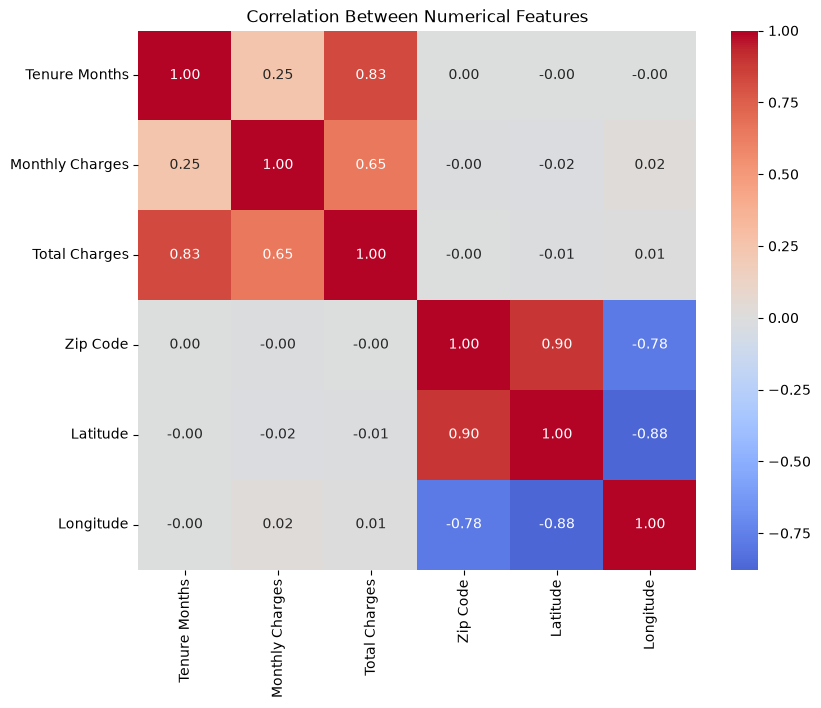

In [26]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
        annot=True,
        fmt=".2f",
    cmap="coolwarm",
        center=0

)
plt.title("Correlation Between Numerical Features")

plt.show()

### Correlation Observations

The correlation analysis shows several important relationships between the numerical features.

- `Total Charges` has a strong positive correlation with `Tenure Months` (0.83), which is expected because customers who stay longer have more time to accumulate charges.
- `Total Charges` also has a moderately strong positive correlation with `Monthly Charges` (0.65), indicating that customers with higher monthly charges generally accumulate higher total charges.
- `Tenure Months` and `Monthly Charges` have a relatively weak correlation (0.25), suggesting that the amount a customer pays each month is not strongly determined by how long they have been a customer.
- `Zip Code` and `Latitude` have a strong positive correlation (0.90), while `Latitude` and `Longitude` also show a strong negative correlation (-0.88). These relationships are expected because these variables describe geographic location.
- `Zip Code`, `Latitude`, and `Longitude` have almost no correlation with the customer billing and tenure features.

The strong relationship between `Total Charges`, `Tenure Months`, and `Monthly Charges` should be considered during feature engineering because these variables contain overlapping information.

## 5. Relationships Between Categorical Features

The previous analysis showed that several service-related features have similar relationships with churn.

Before creating new features, I will examine whether these categorical variables are also related to each other. This can help identify overlapping information and guide later feature engineering decisions.

In [27]:
service_features = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

service_crosstab = pd.crosstab(
    df["Online Security"],
    df["Tech Support"],
    normalize="index"
)

service_crosstab

Tech Support,No,No internet service,Yes
Online Security,,,
No,0.729846,0.0,0.270154
No internet service,0.000000,1.0,0.000000
Yes,0.455671,0.0,0.544329


### Service Feature Relationships

The previous comparison showed that `Online Security` and `Tech Support` are related, but they are not identical.

I will now examine the relationships among the main service-related features to determine whether they contain overlapping information or represent different aspects of customer service adoption.

In [28]:
for i in range(len(service_features)):
    for j in range(i + 1, len(service_features)):
        
        col1 = service_features[i]
        col2 = service_features[j]
        
        print(f"\n{col1} vs {col2}")
        
        print(
            pd.crosstab(
                df[col1],
                df[col2],
                normalize="index"
            ).round(2)
        )


Online Security vs Online Backup
Online Backup          No  No internet service   Yes
Online Security                                     
No                   0.63                  0.0  0.37
No internet service  0.00                  1.0  0.00
Yes                  0.44                  0.0  0.56

Online Security vs Device Protection
Device Protection      No  No internet service   Yes
Online Security                                     
No                   0.63                  0.0  0.37
No internet service  0.00                  1.0  0.00
Yes                  0.45                  0.0  0.55

Online Security vs Tech Support
Tech Support           No  No internet service   Yes
Online Security                                     
No                   0.73                  0.0  0.27
No internet service  0.00                  1.0  0.00
Yes                  0.46                  0.0  0.54

Online Security vs Streaming TV
Streaming TV           No  No internet service   Yes
Online Securit

### Observation

The service-related categorical features show noticeable relationships with one another, indicating that customers who subscribe to one additional service are often more likely to subscribe to other services as well.

The strongest relationship is observed between `Streaming TV` and `Streaming Movies`, where customers with one service are substantially more likely to have the other.

`Online Security`, `Online Backup`, `Device Protection`, and `Tech Support` also show relationships with each other, but none of these features appears to be an exact duplicate of another.

Therefore, these features will be retained for the modeling stage. Their relationships will be considered during feature engineering rather than removing them solely because they are associated

## 6. Geographic Analysis

The dataset contains geographic information such as city, zip code, latitude, and longitude.

Since these variables are strongly related to one another, I will investigate whether customer location also shows meaningful differences in churn rates.

In [29]:
city_churn_reliable = (
    df.groupby("City")["Churn Value"]
      .agg(["mean", "count"])
      .query("count >= 30")
      .sort_values("mean", ascending=False)
)

city_churn_reliable.head(15)

,mean,count
City,,
San Diego,0.333333,150
Glendale,0.325000,40
Pasadena,0.300000,30
San Francisco,0.298077,104
Los Angeles,0.295082,305
Berkeley,0.281250,32
Stockton,0.272727,44
San Jose,0.258929,112
Oakland,0.250000,52


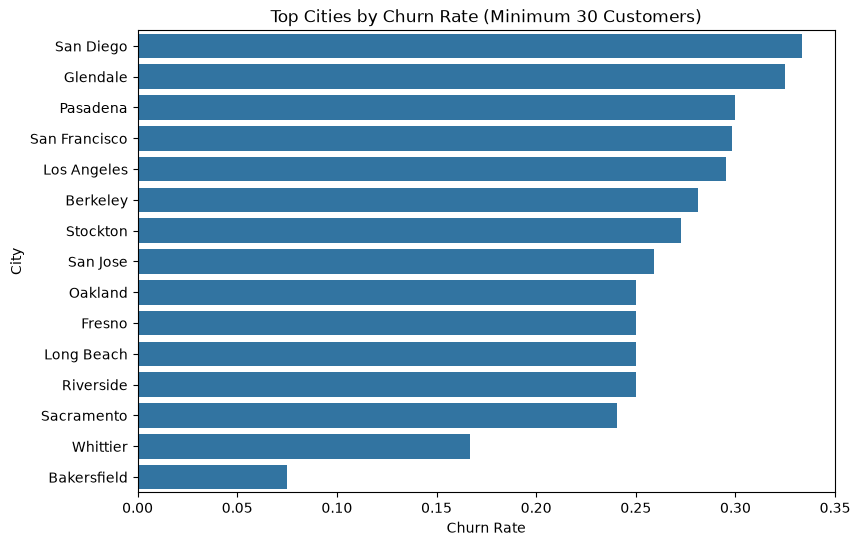

In [30]:
# Let's visualize it
top_cities = city_churn_reliable.head(15)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_cities.reset_index(),
    x="mean",
    y="City"
)

plt.title("Top Cities by Churn Rate (Minimum 30 Customers)")
plt.xlabel("Churn Rate")
plt.ylabel("City")

plt.show()

### Observation

Churn rates vary across cities, even after filtering out cities with very small customer counts.

Some cities show noticeably higher churn rates, while others have considerably lower rates. This suggests that geographic location may contain some predictive information about customer churn.

However, the difference in churn rates should not be interpreted as a causal relationship. Other customer characteristics may explain part of the observed variation.

Therefore, geographic information will be considered during feature selection and modeling rather than being removed solely based on this analysis.

# Final EDA Summary

After exploring the numerical, categorical, service, and geographic features, several patterns related to customer churn became clear.

### 1. Customer Tenure

Churned customers generally have much lower tenure than customers who stayed. This is one of the clearest patterns observed in the numerical analysis.

This suggests that newer customers may be at a higher risk of leaving.

### 2. Monthly Charges

Churned customers tend to have slightly higher monthly charges. The difference is not extremely large, but the churned group is more concentrated toward higher monthly charges.

This suggests that monthly pricing may have some relationship with churn.

### 3. Total Charges

Churned customers generally have considerably lower total charges than customers who stayed.

This is strongly connected to tenure because customers who leave earlier have had less time to accumulate total charges.

Therefore, Total Charges should be treated carefully during feature engineering because it contains information closely related to Tenure.

### 4. Demographic Features

Gender shows very little difference in churn rate between the two groups.

Senior Citizen status, however, shows a noticeable difference, with senior customers having a considerably higher churn rate.

Partner and Dependents also show differences in churn behavior, suggesting that household characteristics may contain useful predictive information.

### 5. Internet and Additional Services

Internet service shows a noticeable relationship with churn. Customers using Fiber optic internet have a considerably higher churn rate than customers using DSL or having no internet service.

Additional services such as Online Security, Online Backup, Device Protection, and Tech Support also show differences in churn rates.

Customers without some of these additional services generally show higher churn rates.

### 6. Contract and Payment Behavior

Contract type shows one of the strongest relationships with churn.

Month-to-month customers have a substantially higher churn rate than customers with one-year or two-year contracts.

Payment method also shows noticeable differences. Electronic check customers have a considerably higher churn rate than customers using other payment methods.

These features are likely to be useful during modeling.

### 7. Service Feature Relationships

Several additional services are related to one another.

The strongest relationship observed was between Streaming TV and Streaming Movies. Customers who subscribe to one are substantially more likely to subscribe to the other.

However, these features are not identical and still provide potentially useful information, so they will not be removed solely because they are correlated.

### 8. Geographic Features

Churn rates vary across cities, suggesting that geographic information may contain some predictive information.

However, geographic differences should not be interpreted as causal relationships. Other customer characteristics may explain these differences.

Geographic features will therefore be evaluated during feature selection rather than automatically retained or removed.

---

## Overall EDA Conclusion

The analysis suggests that customer churn is not driven by a single variable.

The strongest patterns appear to involve:

- Customer tenure
- Contract type
- Monthly charges
- Internet service
- Additional services
- Payment method
- Senior Citizen status
- Household characteristics

These observations will guide the next stage of the project, where the cleaned dataset will be transformed into features suitable for machine learning models.